STEP 1 - IMPORT LIBRARIES


In [6]:

# y = mx + b
# ============================================
# LINEAR REGRESSION - HOUSE PRICE PREDICTION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

print("All libraries loaded!")

All libraries loaded!


STEP 2 - LOAD CSV FILE

In [7]:
# Load the CSV file

df = pd.read_csv("house_prices.csv")
df

# Explore the data
print(df.shape)  # displays rows and column
print(df.head(2)) # top 2
print(df.tail(2)) # last 2
print(df.info()) # table summary
print(df.describe()) # displays table statistics



(50, 4)
   size  bedrooms  age  price
0   500         1   20  85000
1   620         1   15  95000
    size  bedrooms  age   price
48  4500         6   12  410000
49  4600         6   18  415000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   size      50 non-null     int64
 1   bedrooms  50 non-null     int64
 2   age       50 non-null     int64
 3   price     50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB
None
              size   bedrooms        age         price
count    50.000000  50.000000  50.000000      50.00000
mean   2371.400000   4.300000  15.100000  260380.00000
std    1201.444726   1.488048   7.189136   93637.79326
min     500.000000   1.000000   5.000000   85000.00000
25%    1362.500000   3.000000  10.000000  185750.00000
50%    2150.000000   4.500000  15.000000  256500.00000
75%    3375.000000   6.000000  20.000000  341000.00000

Step 3 - Visualise the data

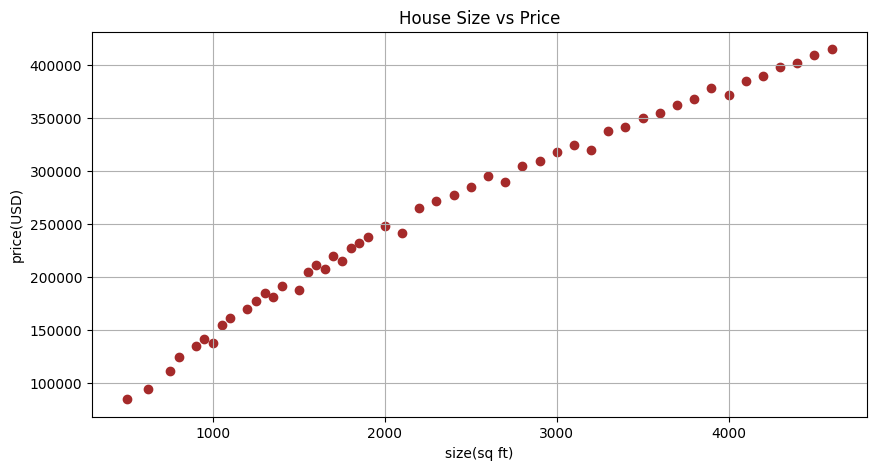

In [8]:
plt.figure(figsize=(10, 5)) # argument for the figure function where 10 is width and 5 is height in inches
plt.scatter(df['size'], df['price'], color='brown')
plt.title('House Size vs Price')
plt.xlabel('size(sq ft)')  # independent variable on the horizontal axis labelled "x"
plt.ylabel('price(USD)')  # dependent variable on the vertical axis labelled "y". ie what we intend to predict
plt.grid(True)  # to display grid
plt.show() # displays everything

STEP 4 - PREPARE AND TRAIN MODEL

In [9]:
# separate input and output
X = df[['size']] #indendent variable without spliting
y = df['price'] #dependent variable without spliting

# split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


model = LinearRegression()
model.fit(X_train, y_train)

print("slope(m)", model.coef_[0])
print("Intercept (b):", model.intercept_)



Training size: (40, 1)
Testing size: (10, 1)
slope(m) 78.26809190117524
Intercept (b): 74016.11107474045


STEP 5- MAKE PREDICTION

In [10]:
# make predictions on the test data
y_pred = model.predict(X_test)

#compare actual vs predicted
results = pd.DataFrame({'Actual Price': y_test.values,
                        'Predicted Price': y_pred.round(1)})

print(results)

   Actual Price  Predicted Price
0        192000         183591.4
1        355000         355781.2
2        290000         285340.0
3        390000         402742.1
4        208000         203158.5
5        410000         426222.5
6        272000         254032.7
7        265000         246205.9
8        310000         300993.6
9        215000         210985.3


STEP 6 - CHECK ACCURACY

In [11]:
# check model accuracy accross diff metrics
print("LINEAR REGRESSION Model Accuracies:")
print("mae:", metrics.mean_absolute_error(y_test, y_pred)) # calc average difference between actual and predicted
print("mse:", metrics.mean_squared_error(y_test, y_pred)) # calc average square diffences between actual and predicted
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2:  ", metrics.r2_score(y_test, y_pred)) # diff R2 interpretation
                                                 # 0.0  =   terrible model
                                                 # 0.5  =   okay model
                                                 # 0.9  =   great model
                                                 #1.0  =   perfect model



LINEAR REGRESSION Model Accuracies:
mae: 9743.851675798252
mse: 131527647.64959629
RMSE: 11468.550372631944
R2:   0.9746682727298017


STEP 7 - VISUALIZE REGRESSION LINE

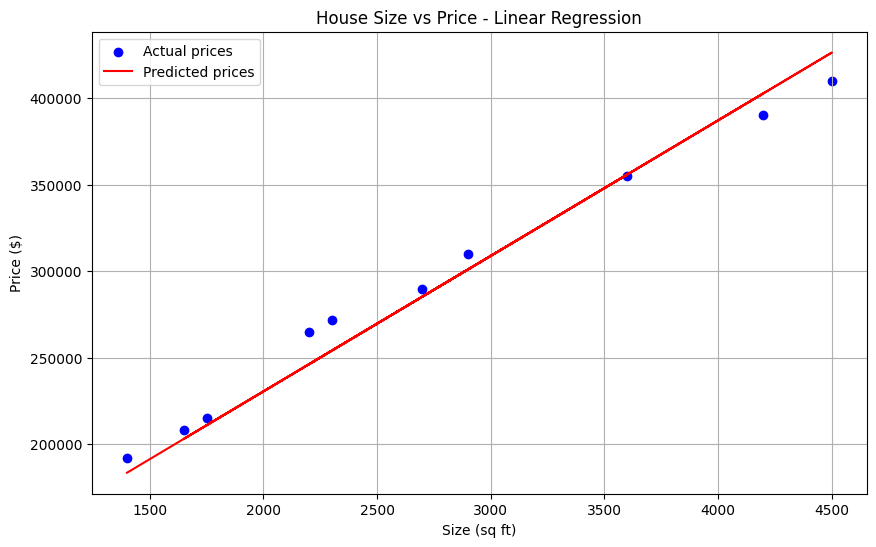

In [12]:
# ============================================
# STEP 7 - VISUALISE REGRESSION LINE
# ============================================

plt.figure(figsize=(10, 6))

# plot actual data points
plt.scatter(X_test, y_test,
            color='blue',
            label='Actual prices')

# plot regression line
plt.plot(X_test, y_pred,
         color='red',
         label='Predicted prices')

plt.title('House Size vs Price - Linear Regression')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()


